# Lab 4: Conjugate Models and Bayesian Updating

**Phân tích dữ liệu Bayesian - IUH**

Từ lab này, việc cập nhật Bayes bắt đầu trở nên gọn gàng một cách đẹp mắt. Ta có một prior, ta nhìn dữ liệu, và posterior thu được vẫn nằm trong cùng một họ phân phối quen thuộc. Chính sự “ăn khớp” ấy làm cho nhiều bài toán tưởng phức tạp bỗng trở nên trong suốt hơn.

Nhưng điều đáng học ở đây không chỉ là sự tiện lợi của công thức. Điều quan trọng hơn là thấy dữ liệu đã đẩy niềm tin ban đầu đi như thế nào, và vì sao trong một số mô hình sự cập nhật ấy lại có thể viết ra thành những quy tắc rất sạch.


In [7]:
# Lab 4 cần cả phân phối chuẩn lẫn các công cụ tính xác suất liên hợp và tích phân số.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad

plt.rcParams["figure.figsize"] = (10, 5)


## 1. Từ prior đến posterior trong các mô hình liên hợp

Lab này đi qua một loạt bối cảnh quen thuộc: xác suất chuẩn, tỷ lệ qua môn, số sinh viên nghỉ học, hay một người thi mãi đến khi đậu. Ở mỗi bài, ta đều bắt đầu với một prior nói lên cách nhìn ban đầu về tham số chưa biết, rồi để dữ liệu điều chỉnh cái nhìn ấy thành posterior.

Điểm đặc biệt của lab là ở nhiều bài, prior và likelihood nói cùng một thứ ngôn ngữ đại số. Vì vậy, posterior không rơi vào một dạng hoàn toàn mới mà vẫn ở trong cùng họ phân phối. Khi điều đó xảy ra, ta nhìn rất rõ dữ liệu đã cộng thêm thông tin vào đâu và bất định còn lại co lại như thế nào.

### Vì sao gọi là các cặp liên hợp?

Một prior và một likelihood được gọi là **liên hợp** nếu sau khi áp dụng công thức Bayes, posterior vẫn thuộc cùng họ phân phối với prior. Điểm hay của liên hợp không chỉ là tính toán gọn, mà còn là việc ta nhìn rất rõ dữ liệu đã làm thay đổi niềm tin trước đó như thế nào.

Về mặt đại số, lý do chúng liên hợp là vì hạt nhân của prior và likelihood có cấu trúc “ăn khớp” với nhau. Khi nhân hai biểu thức lại để tạo posterior không chuẩn hóa, các số mũ hoặc các hạng tử bậc hai chỉ cộng vào nhau, chứ không tạo ra một dạng hàm hoàn toàn mới.

Ví dụ, với prior Beta và likelihood Binomial, ta có phần phụ thuộc vào tham số $p$ dưới dạng:

$$
\pi(p) \propto p^{\alpha-1}(1-p)^{\beta-1}, \qquad
L(p\mid y) \propto p^{y}(1-p)^{n-y}.
$$

Nhân lại với nhau cho posterior không chuẩn hóa:

$$
\pi(p\mid y) \propto p^{\alpha-1+y}(1-p)^{\beta-1+n-y},
$$

và đây vẫn là dạng Beta. Nói ngắn gọn, bài toán liên hợp xảy ra vì số mũ của $p$ và $1-p$ chỉ được cập nhật bằng cách cộng thêm thông tin từ dữ liệu.

Ý tưởng tương tự cũng xảy ra với **prior Beta và likelihood Geometric**: dữ liệu chỉ cộng thêm vào số mũ của $p$ và $1-p$, nên posterior vẫn là Beta. Với **prior Gamma và likelihood Poisson**, prior có dạng lũy thừa nhân với hàm mũ, còn likelihood Poisson cũng cho đúng kiểu hạt nhân đó, nên posterior vẫn là Gamma. Với **prior Normal và likelihood Normal**, tích hai hàm Gaussian theo tham số vẫn cho ra một biểu thức bậc hai trong tham số, nên posterior vẫn là Normal.

Điểm đáng học ở đây là “liên hợp” không phải phép màu thuộc lòng. Nó là hệ quả của việc prior và likelihood có cùng kiểu cấu trúc đại số khi xem như hàm của tham số chưa biết. Chính vì vậy, ở Bài 2 ta sẽ thấy Geometric và Binomial dẫn đến posterior Beta rất gọn, còn Poisson thì không còn gọn như vậy trên miền $[0,1]$ vì cấu trúc posterior không còn khớp hoàn toàn với một họ chuẩn hóa quen thuộc trên đúng support đó.


## 2. Bài 1 - Normal conditional probability và sửa lỗi đề bài

Đề gốc ghi $\sigma=-1$, nhưng độ lệch chuẩn phải dương. Ta sửa thành $\sigma=1$ và tính xác suất điều kiện theo CDF của phân phối chuẩn.

### Ý nghĩa của bài tập

Bài mở đầu này tưởng là một câu tính xác suất điều kiện thuần túy, nhưng nó nhắc một nguyên tắc rất quan trọng trong thống kê Bayesian: trước khi cập nhật hay suy luận gì sâu hơn, ta phải kiểm tra mô hình xác suất có hợp lệ hay không. Một độ lệch chuẩn âm là dấu hiệu cho thấy tham số hóa đã sai ngay từ đầu, nên nếu không dừng lại để sửa, mọi kết quả phía sau đều mất ý nghĩa.

Về mặt học tập, bài này cũng giúp tách bạch hai thao tác thường bị trộn lẫn. Một là xác định đúng mô hình phân phối của biến ngẫu nhiên. Hai là dùng thông tin điều kiện để thu hẹp không gian các giá trị có thể xảy ra. Khi làm chắc bước này, sinh viên sẽ dễ đọc các bài Bayes phía sau hơn vì posterior thực chất cũng là một dạng “điều kiện hóa” niềm tin ban đầu theo dữ liệu quan sát được.


### Đề bài nhắc lại

**Bài 1.** Cho biến ngẫu nhiên $X$ có phân phối chuẩn với $\mu=4$ và đề gốc ghi $\sigma=-1$. Hãy tính
$$P(X\le 0\mid X>-3).$$
Lời giải cần nhận ra và sửa lỗi vì độ lệch chuẩn không thể âm.


### Công thức cốt lõi và cách đọc

Xác suất có điều kiện trong bài chuẩn vẫn bắt đầu từ định nghĩa cơ bản:

$$
P(X\le 0\mid X>-3)=\frac{P(-3<X\le 0)}{P(X>-3)}.
$$

Sau khi sửa lỗi của đề và dùng độ lệch chuẩn dương $$\sigma=1$$, ta đổi về hàm phân phối chuẩn chuẩn hóa:

$$
P(X\le 0\mid X>-3)=\frac{\Phi\left(\frac{0-4}{1}\right)-\Phi\left(\frac{-3-4}{1}\right)}{1-\Phi\left(\frac{-3-4}{1}\right)}.
$$

Công thức này vừa cho lời giải số, vừa nhắc ta rằng độ lệch chuẩn không thể âm. Một mô hình xác suất phải hợp lệ trước khi ta nói đến mọi phép suy luận tiếp theo.


In [8]:
# Bài 1 chỉ cần CDF chuẩn, nhưng vẫn là ví dụ tốt để nhấn mạnh việc kiểm tra tham số hợp lệ trước khi tính toán.
mu = 4
sigma = 1
p_conditional = (stats.norm.cdf(0, mu, sigma) - stats.norm.cdf(-3, mu, sigma)) / (1 - stats.norm.cdf(-3, mu, sigma))
print(f"P(X <= 0 | X > -3) = {p_conditional:.8f}")


P(X <= 0 | X > -3) = 0.00003167


## 3. Bài 2 - Prior $f_X(x)=2x$ và ba likelihood khác nhau

**Bài 2.** Cho $X$ là biến ngẫu nhiên liên tục có hàm mật độ xác suất $$f_X(x) = 2x \text{ với } 0 \le x \le 1.$$ Tìm hậu nghiệm cho $X$ biết rằng các likelihood cho bởi các hàm sau:
- a) Giả sử $Y|X = x \sim Geometric(x)$. 
- b) Giả sử $Y|X = x \sim Binomial(4,x).$ 
- c) Giả sử $Y|X = x \sim Poisson(x).$

Prior $f_X(x)=2x, 0\le x\le 1$ chính là Beta $(2,1)$. Vì vậy, khi likelihood thuộc họ nhị thức hay hình học, posterior thường còn ở dạng Beta. Với Poisson thì liên hợp không còn giữ nguyên, nên posterior chỉ còn được xác định theo mật độ không chuẩn hóa.

### Ý nghĩa của bài tập

Câu này khó ở chỗ đề bài dùng cùng một ký hiệu $X$ cho hai vai trò mà sinh viên mới học Bayes rất dễ trộn lẫn. Nếu đọc theo kiểu xác suất cơ bản, ta có thể tưởng $X$ chỉ là một biến ngẫu nhiên thông thường. Nhưng trong ngữ cảnh Bayesian của bài này, $X$ được xem như **đại lượng chưa biết cần suy ra**. Ta chưa biết giá trị thật của nó là bao nhiêu, nên trước khi thấy dữ liệu ta mô tả mức độ tin tưởng vào các giá trị có thể của $X$ bằng một phân phối prior.

Cụ thể, câu

$$
f_X(x)=2x, \quad 0\le x\le 1
$$

có nghĩa là trước khi quan sát dữ liệu, ta đặt một prior cho $X$ trên đoạn $[0,1]$. Đây là **mật độ prior**, không phải là xác suất tại đúng điểm $x$. Vì $2x$ tăng dần theo $x$, prior này nói rằng trước dữ liệu ta thiên về các giá trị lớn của $x$ hơn các giá trị nhỏ. Nói cách khác, vùng gần $x=0.8$ được prior ưu ái hơn vùng gần $x=0.2$.

Đến câu

$$
Y\mid X=x \sim \text{Geometric}(x),
$$

ta phải đọc thật chậm như sau: **nếu** giá trị thật của đại lượng chưa biết $X$ bằng $x$, thì dữ liệu $Y$ sẽ được sinh ra theo phân phối Geometric với tham số thành công bằng chính $x$. Vì vậy, trong bài này:

- $X$ là tham số ẩn cần suy ra.
- $Y$ là dữ liệu sẽ được quan sát.
- $f_X(x)$ là prior của tham số ẩn.
- $f_{Y\mid X}(y\mid x)$ là likelihood của dữ liệu khi giả sử tham số bằng $x$.

Vì thế, cụm “tìm hậu nghiệm cho $X$” không có nghĩa là tìm phân phối của dữ liệu $Y$. Điều ta cần tìm là phân phối của $X$ **sau khi đã biết dữ liệu** $Y=y$. Đó chính là posterior:

$$
f_{X\mid Y}(x\mid y) \propto f_{Y\mid X}(y\mid x)f_X(x).
$$

Công thức này nói một điều rất tự nhiên: mức độ tin vào giá trị $x$ sau khi thấy dữ liệu sẽ tỷ lệ với hai thành phần. Một là prior $f_X(x)$, tức trước đó ta đã thấy giá trị ấy hợp lý đến đâu. Hai là likelihood $f_{Y\mid X}(y\mid x)$, tức nếu thật sự $X=x$ thì dữ liệu vừa quan sát có hợp lý hay không.

Trong ý a), dữ liệu là một số $y$ cho biết ta phải chờ bao nhiêu lần thử mới có thành công đầu tiên. Nếu dùng quy ước Geometric quen thuộc trong lab này, thì

$$
P(Y=y\mid X=x)=x(1-x)^{y-1}, \qquad y=1,2,3,\dots
$$

Ý nghĩa của biểu thức này rất trực giác: muốn thành công ở lần thứ $y$, ta phải có $y-1$ lần thất bại đầu, rồi đến một lần thành công. Vì xác suất thành công mỗi lần là $x$, nên xác suất của chuỗi đó là $x(1-x)^{y-1}$.

Bây giờ ta ghép likelihood với prior. Prior cho ta $f_X(x)=2x$, còn likelihood cho ta $x(1-x)^{y-1}$. Do đó posterior không chuẩn hóa là

$$
f_{X\mid Y}(x\mid y) \propto x(1-x)^{y-1}\cdot 2x = 2x^2(1-x)^{y-1}.
$$

Đây là bước quan trọng nhất của bài. Ta không cần chuẩn hóa ngay; trước hết chỉ cần nhìn dạng đại số. Biểu thức trên có dạng

$$
x^{\alpha-1}(1-x)^{\beta-1},
$$

chính là kernel của phân phối Beta. So sánh số mũ, ta thấy $x^2 = x^{3-1}$ và $(1-x)^{y-1}$ giữ nguyên, nên posterior sẽ là Beta$(3,y)$.

Trực giác cuối cùng là thế này: nếu $y$ nhỏ, tức thành công đến rất sớm, dữ liệu đang ủng hộ các giá trị lớn của $x$. Nếu $y$ lớn, tức phải chờ rất lâu mới thành công, dữ liệu kéo niềm tin về các giá trị nhỏ hơn của $x$. Posterior là kết quả dung hòa giữa xu hướng ban đầu của prior $2x$ và thông tin mới mà dữ liệu $Y=y$ mang lại.


### Đề bài nhắc lại

**Bài 2.** Cho $X$ là biến ngẫu nhiên liên tục có mật độ prior
$$f_X(x)=2x,\quad 0\le x\le 1.$$
Tìm hậu nghiệm của $X$ trong ba trường hợp likelihood:
- a) $Y\mid X=x \sim \text{Geometric}(x)$
- b) $Y\mid X=x \sim \text{Binomial}(4,x)$
- c) $Y\mid X=x \sim \text{Poisson}(x)$


### Công thức cốt lõi và cách đọc

Prior $$f_X(x)=2x$$ trên đoạn $$[0,1]$$ chính là phân phối Beta$(2,1)$$. Vì vậy, ở hai likelihood đầu, posterior còn giữ dạng Beta.

Với quan sát hình học $$Y=y$$:

$$
p(x\mid y) \propto x(1-x)^{y-1}\cdot 2x = 2x^2(1-x)^{y-1},
$$

nên posterior là:

$$
X\mid y \sim \mathrm{Beta}(3,y).
$$

Với quan sát nhị thức $$Y=y$$ trên 4 phép thử:

$$
p(x\mid y) \propto x^y(1-x)^{4-y}\cdot 2x = 2x^{y+1}(1-x)^{4-y},
$$

nên posterior là:

$$
X\mid y \sim \mathrm{Beta}(y+2, 5-y).
$$

Với Poisson, cấu trúc liên hợp bị mất:

$$
p(x\mid y) \propto \frac{e^{-x}x^y}{y!}\cdot 2x \propto x^{y+1}e^{-x}\mathbf{1}_{[0,1]}(x).
$$

Bài này cho thấy liên hợp không phải một phép màu cố định, mà phụ thuộc vào việc prior và likelihood có ăn khớp đại số với nhau hay không.


/var/folders/y9/c3slzxfd321fc72y_8f52hl00000gn/T/ipykernel_54124/4278807125.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_const = np.trapz(unnorm_pois, x)


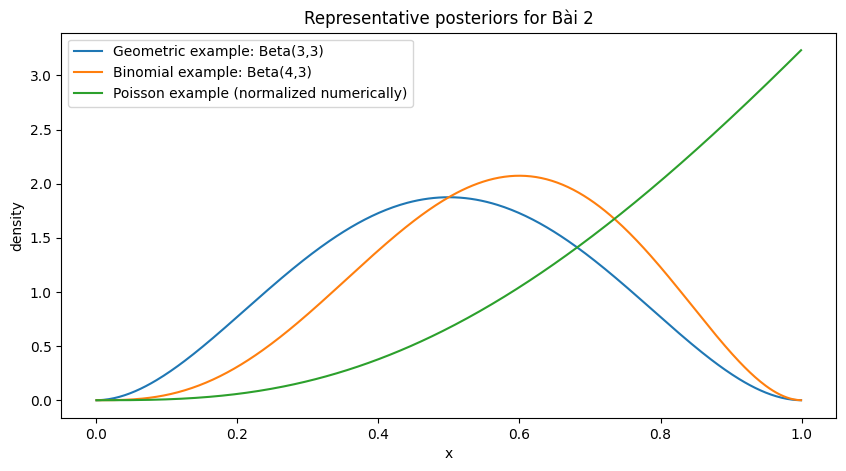

In [9]:
# Phiên bản 1: giữ nguyên ký hiệu của đề gốc, trong đó x là giá trị của tham số ẩn đang được suy luận.
# Example observations for visualization: geometric y=3, binomial y=2, poisson y=2
x = np.linspace(0.001, 0.999, 400)
post_geo = stats.beta.pdf(x, 3, 3)          # Beta(3, y) with y=3
post_bin = stats.beta.pdf(x, 4, 3)          # Beta(y+2, 5-y) with y=2
unnorm_pois = 2 * x**3 * np.exp(-x)         # proportional to x^(y+1) e^{-x}, y=2
norm_const = np.trapezoid(unnorm_pois, x)
post_pois = unnorm_pois / norm_const

plt.plot(x, post_geo, label='Geometric example: Beta(3,3)')
plt.plot(x, post_bin, label='Binomial example: Beta(4,3)')
plt.plot(x, post_pois, label='Poisson example (normalized numerically)')
plt.legend()
plt.title('Bài 2 - Phiên bản 1 theo đề gốc')
plt.xlabel('x (tham số ẩn theo đề gốc)')
plt.ylabel('density')
plt.show()


### Phiên bản 1 - Theo đề gốc: công thức hậu nghiệm

- Nếu $Y\mid X=x\sim \text{Geometric}(x)$ và quan sát $Y=y$, thì
$$f(x\mid y) \propto x(1-x)^{y-1}\cdot 2x = 2x^2(1-x)^{y-1},$$
nên posterior là Beta$\,(3,y)$.

- Nếu $Y\mid X=x\sim \text{Binomial}(4,x)$ và quan sát $Y=y$, thì
$$f(x\mid y) \propto x^y(1-x)^{4-y}\cdot 2x,$$
nên posterior là Beta$\,(y+2,5-y)$.

- Nếu $Y\mid X=x\sim \text{Poisson}(x)$ và quan sát $Y=y$, thì
$$f(x\mid y) \propto e^{-x}x^y\cdot 2x = 2x^{y+1}e^{-x}, \quad 0\le x\le 1,$$
đây không còn là một họ liên hợp chuẩn trên đoạn $[0,1]$.


### Phiên bản 2 - Đặt tên chuẩn Bayes

Sau khi đã xem bản viết theo đề gốc, ta có thể viết lại toàn bộ bài theo ký hiệu Bayesian quen thuộc hơn như sau:

- Gọi $\theta$ là **tham số ẩn** cần suy ra, với $0\le \theta\le 1$.
- Prior của tham số là
$$
p(\theta)=2\theta, \qquad 0\le \theta\le 1.
$$
- Dữ liệu quan sát vẫn ký hiệu là $Y=y$.

Khi đó, bài toán không còn đọc là “tìm hậu nghiệm cho biến $X$”, mà đọc rõ hơn là: **tìm phân phối hậu nghiệm của tham số $\theta$ sau khi quan sát $Y=y$**. Công thức Bayes chuẩn là
$$
p(\theta\mid y) \propto p(y\mid \theta)\,p(\theta).
$$

Với cách đặt tên này, ba ý của bài trở nên rõ hơn:

- **Geometric:** nếu $Y\mid \theta \sim \text{Geometric}(\theta)$, thì
$$
p(\theta\mid y) \propto \theta(1-\theta)^{y-1}\cdot 2\theta = 2\theta^2(1-\theta)^{y-1},
$$
nên $\theta\mid y \sim \text{Beta}(3,y)$.

- **Binomial:** nếu $Y\mid \theta \sim \text{Binomial}(4,\theta)$, thì
$$
p(\theta\mid y) \propto \theta^y(1-\theta)^{4-y}\cdot 2\theta,
$$
nên $\theta\mid y \sim \text{Beta}(y+2,5-y)$.

- **Poisson:** nếu $Y\mid \theta \sim \text{Poisson}(\theta)$, thì
$$
p(\theta\mid y) \propto e^{-\theta}\theta^y\cdot 2\theta = 2\theta^{y+1}e^{-\theta}, \qquad 0\le \theta\le 1,
$$
nên posterior chỉ được xác định theo mật độ không chuẩn hóa trên đoạn $[0,1]$ chứ không còn là một họ liên hợp chuẩn quen thuộc.

Tóm lại, nếu đọc theo ký hiệu chuẩn thì ta nên hiểu:
$$
X \text{ trong đề gốc } \longleftrightarrow \theta \text{ trong ký hiệu chuẩn.}
$$
Việc đổi tên này không làm thay đổi toán học của bài, nhưng giúp tránh cảm giác rằng cùng một ký hiệu vừa là biến ngẫu nhiên, vừa là tham số, vừa là trục đang đem đi vẽ.


In [ ]:
# Phiên bản 2: viết lại cùng ví dụ với ký hiệu chuẩn Bayes, trong đó theta là tham số ẩn và y là dữ liệu quan sát.
theta_grid = np.linspace(0.001, 0.999, 400)
y_geo = 3
y_bin = 2
y_pois = 2

posterior_geo = stats.beta.pdf(theta_grid, 3, y_geo)              # theta | y ~ Beta(3, y)
posterior_bin = stats.beta.pdf(theta_grid, y_bin + 2, 5 - y_bin)  # theta | y ~ Beta(y+2, 5-y)
unnorm_posterior_pois = 2 * theta_grid**(y_pois + 1) * np.exp(-theta_grid)
pois_norm_const = np.trapezoid(unnorm_posterior_pois, theta_grid)
posterior_pois = unnorm_posterior_pois / pois_norm_const

plt.plot(theta_grid, posterior_geo, label='Geometric: p(theta | y) with y=3')
plt.plot(theta_grid, posterior_bin, label='Binomial: p(theta | y) with y=2')
plt.plot(theta_grid, posterior_pois, label='Poisson: normalized p(theta | y) with y=2')
plt.legend()
plt.title('Bài 2 - Phiên bản 2 với ký hiệu chuẩn Bayes')
plt.xlabel('theta (tham số ẩn)')
plt.ylabel('posterior density')
plt.show()


## 4. Bài 3 - Beta-Binomial cho tỷ lệ qua môn

Bài này chuyển từ công thức liên hợp trừu tượng sang một bối cảnh rất gần với thực hành thống kê: suy luận về tỷ lệ thành công trong một quần thể. Prior không còn là một hàm được cho sẵn hoàn toàn, mà được mô tả gián tiếp qua mean và standard deviation. Điều đó phản ánh đúng cách kiến thức chuyên gia thường xuất hiện trong thực tế: người ta hiếm khi nói ngay $\alpha, \beta$ bằng bao nhiêu, mà thường phát biểu dưới dạng “tôi tin tỷ lệ này quanh mức 0.8 và không quá bất định”.

### Ý nghĩa của bài tập

Ý nghĩa lớn nhất của bài này là cho thấy prior có thể được xây từ trực giác miền kiến thức rồi mới chuyển thành tham số toán học. Đây là bước rất quan trọng trong Bayesian workflow, vì nếu sinh viên chỉ quen nhận sẵn Beta$(\alpha,\beta)$ thì sẽ khó kết nối mô hình với phát biểu thực tế của chuyên gia hay giảng viên.

Ngoài ra, bài còn giúp hiểu posterior variance không chỉ là một con số kỹ thuật. Khi đề nhắc tới “rủi ro hậu nghiệm” dưới mất mát bình phương, ta học được rằng bất định còn lại sau dữ liệu cũng là một phần của câu trả lời, không chỉ riêng posterior mean. Nói cách khác, bài này dạy ta rằng Bayesian inference vừa cập nhật giá trị trung tâm, vừa cập nhật mức độ chắc chắn quanh giá trị đó.


### Đề bài nhắc lại

**Bài 3.** Tỷ lệ qua môn Bayesian được cho là có prior Beta với mean $80\%$ và độ lệch chuẩn $10\%$. Trong học kỳ vừa rồi có $40$ sinh viên thì $35$ em qua môn.

- a) Tìm phân phối hậu nghiệm.
- b) Tính rủi ro hậu nghiệm.
- c) Vẽ đồ thị prior và posterior.



### Phiên bản 1 - Theo đề gốc

Ở bản này, ta giữ nguyên cách đọc của đề: prior được mô tả bằng mean và standard deviation, rồi mới suy ra các tham số Beta cụ thể trước khi cập nhật bằng dữ liệu đậu/rớt.


### Công thức cốt lõi và cách đọc

Nếu prior Beta có mean $$m=0.8$$ và độ lệch chuẩn $$s=0.1$$, thì với Beta$(\alpha_0,\beta_0)$$ ta dùng hai công thức:

$$
\frac{\alpha_0}{\alpha_0+\beta_0}=m,
$$

$$
\frac{\alpha_0\beta_0}{(\alpha_0+\beta_0)^2(\alpha_0+\beta_0+1)}=s^2.
$$

Từ đó suy ra $$\alpha_0=12$$ và $$\beta_0=3$$. Khi quan sát $$y=35$$ sinh viên qua môn trong $$n=40$$ sinh viên, posterior là:

$$
\theta\mid y \sim \mathrm{Beta}(\alpha_0+y,\beta_0+n-y)=\mathrm{Beta}(47,8).
$$

Nếu đọc rủi ro hậu nghiệm theo mất mát bình phương, đại lượng tự nhiên nhất là posterior variance:

$$
\mathrm{Var}(\theta\mid y)=\frac{47\cdot 8}{55^2\cdot 56}.
$$

Điểm hay của bài là prior ban đầu được phát biểu bằng trực giác miền kiến thức, rồi mới chuyển sang tham số toán học để cập nhật.


Prior Beta(alpha=12.0, beta=3.0)
Posterior Beta(alpha=47.0, beta=8.0)
Posterior risk (variance) = 0.002220


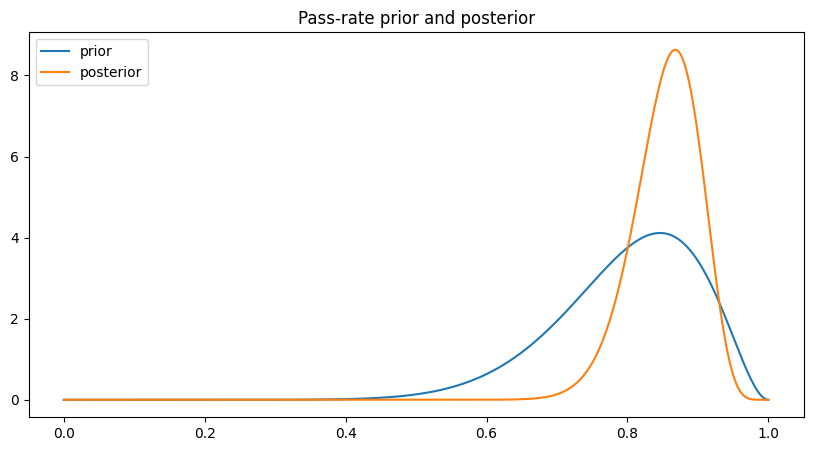

In [10]:
# Phiên bản 1: giữ nguyên cách đặt tên gần với đề gốc, trong đó prior được cho qua mean và standard deviation của tỷ lệ qua môn.
mean_prior = 0.8
sd_prior = 0.1
var_prior = sd_prior**2
kappa = mean_prior * (1 - mean_prior) / var_prior - 1
alpha_prior = mean_prior * kappa
beta_prior = (1 - mean_prior) * kappa
alpha_post = alpha_prior + 35
beta_post = beta_prior + 5
posterior_risk = alpha_post * beta_post / ((alpha_post + beta_post)**2 * (alpha_post + beta_post + 1))

print(f"Prior Beta(alpha={alpha_prior:.1f}, beta={beta_prior:.1f})")
print(f"Posterior Beta(alpha={alpha_post:.1f}, beta={beta_post:.1f})")
print(f"Posterior risk (variance) = {posterior_risk:.6f}")

p = np.linspace(0, 1, 400)  # p ở đây là tỷ lệ qua môn theo cách viết quen thuộc của đề
plt.plot(p, stats.beta.pdf(p, alpha_prior, beta_prior), label='prior')
plt.plot(p, stats.beta.pdf(p, alpha_post, beta_post), label='posterior')
plt.legend()
plt.title('Bài 3 - Phiên bản 1 theo đề gốc')
plt.xlabel('p (tỷ lệ qua môn theo đề gốc)')
plt.ylabel('density')
plt.show()


### Interpretation

Từ mean 0.8 và độ lệch chuẩn 0.1, prior suy ra Beta$(12,3)$. Sau khi quan sát 35 sinh viên đậu trong 40 em, posterior trở thành Beta$(47,8)$. “Rủi ro hậu nghiệm” dưới mất mát bình phương được đọc tự nhiên nhất là posterior variance, phản ánh mức bất định còn lại về tỷ lệ qua môn sau khi nhìn dữ liệu.


### Phiên bản 2 - Đặt tên chuẩn Bayes cho tỷ lệ qua môn

Nếu muốn viết lại bài này theo ký hiệu Bayesian chuẩn hơn, ta nên gọi $\theta$ là **xác suất qua môn thật sự** của quần thể sinh viên. Khi đó:

- Prior là $\theta \sim \text{Beta}(\alpha_0,\beta_0)$, nhưng đề không cho trực tiếp $\alpha_0,\beta_0$ mà cho mean và standard deviation.
- Dữ liệu là $Y\mid \theta \sim \text{Binomial}(n,\theta)$ với $n=40$ và $y=35$.
- Posterior chuẩn là
$$
\theta\mid y \sim \text{Beta}(\alpha_0+y,\beta_0+n-y).
$$

Cách viết này giúp ta nhìn bài như một cặp liên hợp rất điển hình: prior Beta cho tham số tỷ lệ, likelihood Binomial cho số sinh viên qua môn. Dữ liệu chỉ làm nhiệm vụ cộng thêm số đậu vào tham số thứ nhất và số rớt vào tham số thứ hai.

Về mặt ký hiệu, bản chuẩn đọc như sau:
$$
\theta \text{ là tỷ lệ qua môn chưa biết},\qquad Y \text{ là số sinh viên qua môn quan sát được.}
$$
Điều này thường rõ hơn cách vừa nói “tỷ lệ qua môn” vừa dùng ký hiệu $p$ hay các biến trung gian mà chưa nêu rõ đâu là tham số ẩn, đâu là dữ liệu.


In [ ]:
# Phiên bản 2: viết lại cùng bài toán với ký hiệu chuẩn Bayes, trong đó theta là xác suất qua môn thật sự.
theta_prior_mean = 0.8
theta_prior_sd = 0.1
theta_prior_var = theta_prior_sd**2
prior_concentration = theta_prior_mean * (1 - theta_prior_mean) / theta_prior_var - 1
alpha_0 = theta_prior_mean * prior_concentration
beta_0 = (1 - theta_prior_mean) * prior_concentration
n_students = 40
y_pass = 35
alpha_n = alpha_0 + y_pass
beta_n = beta_0 + n_students - y_pass
posterior_variance = alpha_n * beta_n / ((alpha_n + beta_n)**2 * (alpha_n + beta_n + 1))

print(f"Prior: theta ~ Beta({alpha_0:.1f}, {beta_0:.1f})")
print(f"Posterior: theta | y ~ Beta({alpha_n:.1f}, {beta_n:.1f})")
print(f"Posterior variance = {posterior_variance:.6f}")

theta_grid = np.linspace(0, 1, 400)
plt.plot(theta_grid, stats.beta.pdf(theta_grid, alpha_0, beta_0), label='prior for theta')
plt.plot(theta_grid, stats.beta.pdf(theta_grid, alpha_n, beta_n), label='posterior for theta')
plt.legend()
plt.title('Bài 3 - Phiên bản 2 với ký hiệu chuẩn Bayes')
plt.xlabel('theta (xác suất qua môn thật sự)')
plt.ylabel('density')
plt.show()


## 5. Bài 4 - Uniform prior và thi đến khi đậu

Nếu Nam thi đến khi đậu và đã cần đúng 3 lần, thì dữ liệu tương ứng với hai lần trượt trước rồi một lần đậu ở lần thứ ba. Likelihood theo $p$ là $p(1-p)^2$. Prior là đều trên đoạn $(0.75,1)$, nên posterior chỉ khác likelihood bởi hằng số chuẩn hóa trên đoạn này.

### Ý nghĩa của bài tập

Bài này rất đáng học vì nó buộc ta đọc dữ liệu như một chuỗi có thứ tự thời gian, chứ không chỉ như tổng số lần thành công hay thất bại. “Đậu ở lần thứ ba” không giống với “có đúng một lần đậu trong ba lần”, và chính cách diễn đạt đó quyết định dạng likelihood hình học. Đây là bước quan trọng để sinh viên hiểu rằng likelihood luôn phụ thuộc vào cơ chế sinh dữ liệu, không chỉ vào các con số đếm cuối cùng.

Bài cũng nhấn mạnh một ý Bayesian rất đẹp: prior có thể mang thông tin miền rất mạnh. Việc chỉ cho phép $p$ nằm trong khoảng $(0.75,1)$ có nghĩa là trước dữ liệu ta đã tin Nam là một thí sinh khá giỏi. Posterior vì thế không chỉ phản ánh ba lần thi, mà là sự dung hòa giữa niềm tin ban đầu và dữ liệu quan sát được trong một bối cảnh cụ thể.


### Đề bài nhắc lại

**Bài 4.** Xác suất Nam đậu TOEIC là $p$ với prior đều trên $(0.75,1)$. Nam thi cho đến khi đậu và biết rằng em đã thi đúng 3 lần. Tìm mật độ hậu nghiệm của $p$ và tính xác suất $p<0.8$.


### Công thức cốt lõi và cách đọc

Dữ liệu thi đúng 3 lần mới đậu phải được đọc như chuỗi trượt, trượt, rồi đậu. Vì vậy likelihood theo xác suất đậu $$p$$ là:

$$
P(Y=3\mid p)=(1-p)^2p.
$$

Prior của $$p$$ là đều trên đoạn $$(0.75,1)$$, nên posterior chỉ khác likelihood bởi hằng số chuẩn hóa trên chính đoạn đó:

$$
p(p\mid Y=3) \propto p(1-p)^2\mathbf{1}_{(0.75,1)}(p).
$$

Xác suất quan tâm được tính bằng tỉ số hai tích phân:

$$
P(p<0.8\mid Y=3)=\frac{\int_{0.75}^{0.8} p(1-p)^2\,dp}{\int_{0.75}^{1} p(1-p)^2\,dp}.
$$

Đây là ví dụ rất tốt cho việc likelihood phải bám sát câu chuyện sinh dữ liệu chứ không chỉ bám vào số lần thành công và thất bại.


In [11]:
# Bài thi TOEIC: likelihood đến từ việc “trượt, trượt, rồi đậu”, còn posterior chỉ cần chuẩn hóa trên khoảng prior.
def unnorm_toeic_posterior(p):
    return p * (1 - p)**2 if 0.75 <= p <= 1 else 0.0

norm_const, _ = quad(unnorm_toeic_posterior, 0.75, 1)
prob_p_less_08, _ = quad(unnorm_toeic_posterior, 0.75, 0.8)
prob_p_less_08 /= norm_const
print(f"P(p < 0.8 | data) = {prob_p_less_08:.6f}")


P(p < 0.8 | data) = 0.464369


## 6. Bài 5 - Gamma-Poisson cho số sinh viên nghỉ học

Từ mean 3 và độ lệch chuẩn 2, với tham số hóa Gamma(shape, rate), ta có shape = 2.25 và rate = 0.75. Quan sát Poisson theo từng tuần giúp posterior cập nhật rất gọn: chỉ cần cộng số nghỉ vào shape và cộng số tuần vào rate.

### Ý nghĩa của bài tập

Đây là ví dụ rất tốt để thấy conjugacy hữu ích thế nào trong các bài toán đếm theo thời gian. Khi dữ liệu đến theo từng tuần, ta không cần làm lại toàn bộ bài toán từ đầu; chỉ cần cập nhật vài tham số của posterior. Điều này phản ánh đúng tinh thần “learning from data” của Bayes: kiến thức hiện tại luôn có thể trở thành prior cho vòng cập nhật tiếp theo.

Bài này cũng giúp sinh viên nhìn rõ sự khác nhau giữa dữ liệu cá thể và dữ liệu tổng hợp theo khoảng thời gian. Ta không theo dõi từng sinh viên nghỉ học riêng lẻ, mà mô hình hóa tổng số nghỉ trong mỗi tuần bằng Poisson. Vì vậy, câu hỏi thống kê được chuyển thành suy luận về một tốc độ trung bình ẩn $\lambda$, và posterior cho biết sau nhiều tuần quan sát ta hiểu tốc độ đó rõ đến đâu.


### Đề bài nhắc lại

**Bài 5.** Số sinh viên nghỉ học không phép mỗi tuần có prior Gamma với trung bình $3$ và độ lệch chuẩn $2$. Quan sát 8 tuần vừa rồi cho dãy Poisson
$$2,0,2,3,2,0,2,4.$$
Hãy tìm phân phối hậu nghiệm và vẽ đồ thị cập nhật sau từng lần quan sát.



### Phiên bản 1 - Theo đề gốc

Ở bản này, ta giữ cách phát biểu của đề: prior Gamma được cho qua mean và standard deviation, còn dữ liệu là chuỗi số sinh viên nghỉ học quan sát theo từng tuần.


### Công thức cốt lõi và cách đọc

Với tham số hóa Gamma(shape, rate), nếu prior có mean $$3$$ và độ lệch chuẩn $$2$$ thì:

$$
\alpha_0=\left(\frac{3}{2}\right)^2=2.25,
\qquad
\beta_0=\frac{3}{2^2}=0.75.
$$

Khi dữ liệu hàng tuần tuân theo $$Y_t\mid \lambda \sim \mathrm{Poisson}(\lambda)$$, posterior sau $$n$$ tuần là:

$$
\lambda\mid y_{1:n} \sim \mathrm{Gamma}\left(\alpha_0+\sum_{t=1}^{n} y_t,\ \beta_0+n\right).
$$

Vì vậy cập nhật tuần tự có dạng rất gọn:

$$
\alpha_t=\alpha_{t-1}+y_t,
\qquad
\beta_t=\beta_{t-1}+1.
$$

Ý nghĩa của bài là mỗi tuần mới chỉ làm thay đổi hai tham số của posterior, nhưng lại thay đổi trực tiếp cách ta hiểu về tốc độ nghỉ học trung bình $$\lambda$$.


 prior: Gamma(shape=2.25, rate=0.75), mean=3.000
week 1: Gamma(shape=4.25, rate=1.75), mean=2.429
week 2: Gamma(shape=4.25, rate=2.75), mean=1.545
week 3: Gamma(shape=6.25, rate=3.75), mean=1.667
week 4: Gamma(shape=9.25, rate=4.75), mean=1.947
week 5: Gamma(shape=11.25, rate=5.75), mean=1.957
week 6: Gamma(shape=11.25, rate=6.75), mean=1.667
week 7: Gamma(shape=13.25, rate=7.75), mean=1.710
week 8: Gamma(shape=17.25, rate=8.75), mean=1.971


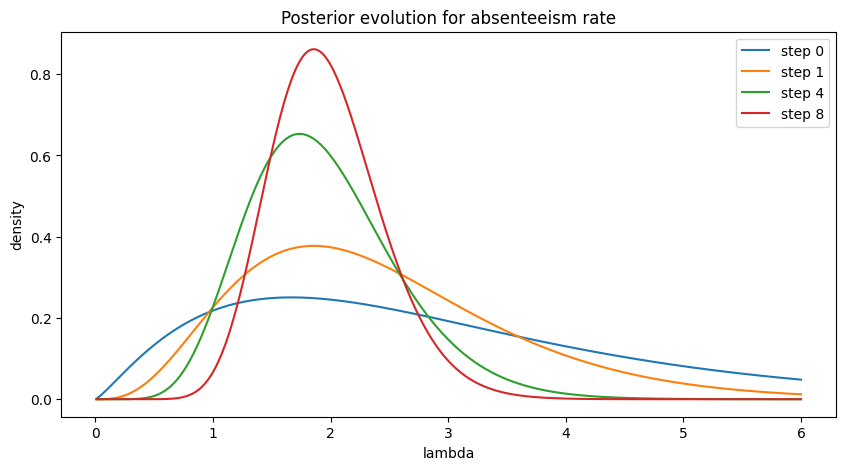

In [12]:
# Phiên bản 1: giữ nguyên cách kể của đề gốc, trong đó số nghỉ học mỗi tuần được cập nhật tuần tự bằng cặp Gamma-Poisson.
prior_shape = 2.25
prior_rate = 0.75
weekly_counts = [2, 0, 2, 3, 2, 0, 2, 4]
shapes = [prior_shape]
rates = [prior_rate]
for y in weekly_counts:
    shapes.append(shapes[-1] + y)
    rates.append(rates[-1] + 1)

for week, (a, b) in enumerate(zip(shapes, rates)):
    label = 'prior' if week == 0 else f'week {week}'
    print(f"{label:>6}: Gamma(shape={a:.2f}, rate={b:.2f}), mean={a/b:.3f}")

lam = np.linspace(0.01, 6, 400)  # lambda là tốc độ nghỉ học trung bình theo cách viết quen thuộc
for idx in [0, 1, 4, 8]:
    plt.plot(lam, stats.gamma.pdf(lam, a=shapes[idx], scale=1/rates[idx]), label=f'step {idx}')
plt.legend()
plt.xlabel('lambda (tốc độ nghỉ học trung bình)')
plt.ylabel('density')
plt.title('Bài 5 - Phiên bản 1 theo đề gốc')
plt.show()


### Phiên bản 2 - Đặt tên chuẩn Bayes cho tốc độ nghỉ học

Nếu viết bài này theo ký hiệu Bayes chuẩn, ta nên gọi $\lambda$ là **tốc độ nghỉ học trung bình mỗi tuần** chưa biết. Khi đó:

- Prior là $\lambda \sim \text{Gamma}(\alpha_0,\beta_0)$ theo tham số hóa shape-rate.
- Dữ liệu là các quan sát $Y_1,\dots,Y_8 \mid \lambda \sim \text{Poisson}(\lambda)$ độc lập có điều kiện.
- Với dãy dữ liệu $y_1,\dots,y_8$, posterior sau toàn bộ 8 tuần là
$$
\lambda \mid y_{1:8} \sim \text{Gamma}\left(\alpha_0+\sum_{t=1}^8 y_t,\ \beta_0+8\right).
$$

Cách đặt tên này giúp ta thấy rõ cấu trúc của bài: $\lambda$ là tham số ẩn, còn $Y_t$ là dữ liệu đếm theo từng tuần. Mỗi tuần mới chỉ làm tăng shape theo số nghỉ quan sát được và tăng rate thêm 1 đơn vị thời gian.

Đây là cách viết đặc biệt hữu ích khi sau này ta học posterior predictive hoặc các mô hình Poisson regression, vì khi đó việc phân biệt rõ tham số ẩn và dữ liệu theo chỉ số thời gian trở nên rất quan trọng.


In [ ]:
# Phiên bản 2: viết lại bài bằng ký hiệu chuẩn Bayes, trong đó lambda là tốc độ nghỉ học trung bình mỗi tuần.
alpha_0 = 2.25
beta_0 = 0.75
y_observed = np.array([2, 0, 2, 3, 2, 0, 2, 4])
alpha_path = [alpha_0]
beta_path = [beta_0]
for y_t in y_observed:
    alpha_path.append(alpha_path[-1] + y_t)
    beta_path.append(beta_path[-1] + 1)

for t, (alpha_t, beta_t) in enumerate(zip(alpha_path, beta_path)):
    label = 'prior' if t == 0 else f'week {t}'
    print(f"{label:>6}: lambda | data ~ Gamma(shape={alpha_t:.2f}, rate={beta_t:.2f}), mean={alpha_t/beta_t:.3f}")

lambda_grid = np.linspace(0.01, 6, 400)
for idx in [0, 1, 4, 8]:
    plt.plot(lambda_grid, stats.gamma.pdf(lambda_grid, a=alpha_path[idx], scale=1/beta_path[idx]), label=f'step {idx}')
plt.legend()
plt.title('Bài 5 - Phiên bản 2 với ký hiệu chuẩn Bayes')
plt.xlabel('lambda (tốc độ nghỉ học trung bình mỗi tuần)')
plt.ylabel('density')
plt.show()


## 7. Model criticism and reflection

Conjugacy rất tiện nhưng không phải lúc nào cũng là mô hình tốt nhất. Bài 4 cho thấy có lúc posterior không nằm trong một họ quen thuộc và phải chuẩn hóa số. Bài 5 cũng nhắc rằng Poisson giả định tốc độ nghỉ học ổn định giữa các tuần; nếu có mùa thi hay biến động đặc biệt, giả định này cần được xem lại.


## 8. Conceptual interpretation questions

1. Vì sao prior Beta lại tự nhiên cho tỷ lệ qua môn?  
2. Trong Bài 4, dữ liệu “đậu ở lần thứ 3” tương ứng với likelihood nào và vì sao?  
3. Bài 5 cho thấy điều gì về vai trò của mean và độ lệch chuẩn khi chuyển prior định tính thành phân phối Gamma cụ thể?  
4. Khi nào conjugate prior giúp ích, và khi nào nó dễ làm ta quên kiểm tra giả định?


## 9. Final takeaway

Lab 4 cho ta thấy Bayesian updating có thể rất gọn khi prior và likelihood ăn khớp nhau, nhưng điều quan trọng hơn là hiểu mỗi phép cập nhật đang nói gì về dữ liệu và về tham số chưa biết.


## 10. Lecture references

Nếu muốn quay lại đúng lecture cho từng cụm bài trong Lab 4, nên đọc lại các phần sau:

- [Bài 0.2: Các Phân phối Xác suất - Mô tả Sự Biến thiên trong Dữ liệu](../../contents/vi/chapter00/_posts/2025-01-02-00_02_common_distributions.md): **Bài 1** đến **Bài 5**: đọc lại Normal, Beta, Gamma, Binomial và Poisson để không lẫn vai trò của prior, likelihood và tham số trong từng bài.
- [Bài 2.2: Likelihood - Câu chuyện về Dữ liệu và Mô hình](../../contents/vi/chapter02/_posts/2025-01-02-02_02_likelihood.md): **Bài 2** và **Bài 4**: đặc biệt cần để viết đúng likelihood khi dữ liệu đến dưới dạng “thành công ở lần thứ ba” hay dưới ba mô hình Geometric, Binomial, Poisson khác nhau.
- [Bài 2.4: Posterior - Cập nhật Niềm tin với Dữ liệu](../../contents/vi/chapter02/_posts/2025-01-02-02_04_posterior.md): **Bài 3**, **Bài 4** và **Bài 5**: đọc lại sơ đồ `prior -> likelihood -> posterior` để thấy dữ liệu đậu/rớt hay số nghỉ học đang cộng thông tin vào đâu.
- [Bài 2.5: Prior liên hợp và đại số của cập nhật Bayes](../../contents/vi/chapter02/_posts/2025-01-02-02_05_conjugate_priors.md): **Bài 2** đến **Bài 5**: đọc lại khi muốn hiểu vì sao Beta-Binomial, Beta-Geometric và Gamma-Poisson cho posterior gọn, còn trường hợp Poisson trên miền $[0,1]$ thì không còn liên hợp trọn vẹn.
